<a href="https://colab.research.google.com/github/5heron/HeliosAI/blob/main/Gayter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# SOLAR PV GLOBAL DATA PIPELINE (FINAL • COLAB SAFE • V4.3 - GLOBAL PER-kWp)
# ==========================================================
# Key changes in V4.3:
# - Target: P_GEN_MAX (power) normalized to pv_per_kw (per kWp)
# - Drop Apparent PV Size after normalization → enforces transferable model
# - Permissive range filter on normalized target
# - Enhanced target diagnostics
# - No other logic changes

!pip -q install pvlib requests openpyxl
import logging
import requests
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
import re
import pvlib
from pvlib.location import Location
from pvlib.irradiance import get_total_irradiance

# ==========================================================
# CONFIG
# ==========================================================
SITE_LAT = 51.5
SITE_LON = -0.1
SITE_ALT = 50.0
SITE_TZ = "Europe/London"
DEFAULT_TILT = 30.0
DEFAULT_AZIMUTH = 180.0
MERGE_TOL = "15min"
TEST_SIZE = 0.2
LAG_HOURS = [1, 2, 3]
TARGET_COL = "pv_per_kw"          # normalized target
RAW_TARGET = "P_GEN_MAX"          # changed from I_GEN_MAX
WEATHER_COLS = ["SolarRad", "TempOut", "OutHum", "DewPt", "WindSpeed", "Rain", "RainRate", "Bar"]

# ==========================================================
# LOGGING & PATHS
# ==========================================================
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)
BASE_DIR = Path("/content")
PV_ZIP = BASE_DIR / "PV_Data.zip"
PV_FOLDER = BASE_DIR / "PV_Data"
INNER_ZIP = PV_FOLDER / "PV Data - csv files only.zip"
WX_FILE = BASE_DIR / "Weather_Data.xlsx"
DEVICE_FILE = PV_FOLDER / "deviceListTable with explanatory notes v2 - customer addresses removed.xlsx"
PV_CSV = PV_FOLDER / "2014-11-28 Cleansed and Processed" / "EXPORT HourlyData" / "EXPORT HourlyData - Customer Endpoints.csv"
PV_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/81fb6b31-f6b2-4e12-b054-090319faec7b/PV%20Data.zip"
WX_URL = "https://data.london.gov.uk/download/photovoltaic-pv-solar-panel-energy-generation-data-2nlqm/b4a7e790-8cb8-451c-b828-c4c5d8445705/Weather%20Data%202014-11-30.xlsx"

# ==========================================================
# DOWNLOAD & EXTRACT
# ==========================================================
def download_and_extract():
    try:
        if not PV_ZIP.exists():
            logger.info("Downloading PV ZIP...")
            r = requests.get(PV_URL, timeout=60)
            r.raise_for_status()
            PV_ZIP.write_bytes(r.content)
        if not PV_FOLDER.exists():
            logger.info("Extracting PV ZIP...")
            with zipfile.ZipFile(PV_ZIP, "r") as z:
                z.extractall(PV_FOLDER)
        if INNER_ZIP.exists():
            logger.info("Extracting inner CSV ZIP...")
            with zipfile.ZipFile(INNER_ZIP, "r") as z:
                z.extractall(PV_FOLDER)
        if not WX_FILE.exists():
            logger.info("Downloading weather XLSX...")
            r = requests.get(WX_URL, timeout=60)
            r.raise_for_status()
            WX_FILE.write_bytes(r.content)
    except Exception as e:
        logger.error(f"Download/extract failed: {e}")
        raise

# ==========================================================
# LOAD & PARSE
# ==========================================================
def load_data():
    if not all([PV_CSV.exists(), WX_FILE.exists(), DEVICE_FILE.exists()]):
        raise FileNotFoundError("Required files missing.")
    pv = pd.read_csv(PV_CSV, low_memory=False)
    pv.columns = pv.columns.str.strip()
    wx = pd.read_excel(WX_FILE)
    wx.columns = wx.columns.str.strip()
    dev = pd.read_excel(DEVICE_FILE)
    dev.columns = dev.columns.str.strip()
    if RAW_TARGET not in pv.columns:
        raise KeyError(f"Missing '{RAW_TARGET}' in PV CSV.")
    logger.info(f"Loaded PV: {pv.shape}, WX: {wx.shape}, Dev: {dev.shape}")
    pv["datetime"] = pd.to_datetime(pv["t_date"].astype(str) + " " + pv["t_time"].astype(str), errors="coerce")
    wx["datetime"] = pd.to_datetime(wx["Date"], errors="coerce") + pd.to_timedelta(wx["Time"].astype(str), errors="coerce")
    pv = pv.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
    wx = wx.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
    return pv, wx, dev

# ==========================================================
# MERGE
# ==========================================================
def merge_data(pv, wx, dev):
    df = pd.merge_asof(pv, wx, on="datetime", direction="nearest", tolerance=pd.Timedelta(MERGE_TOL))
    if RAW_TARGET not in df.columns:
        raise KeyError(f"Missing '{RAW_TARGET}' after merge_asof.")
    df = df.merge(dev, left_on="SerialNo", right_on="Serial Number", how="left")
    logger.info(f"Merged shape: {df.shape}")
    return df

# ==========================================================
# CLEAN
# ==========================================================
def clean_data(df):
    for c in WEATHER_COLS:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].mask(df[c] == '---'), errors="coerce")
    df = df.dropna(subset=[RAW_TARGET]).reset_index(drop=True)
    if "SolarRad" in df.columns:
        df = df[df["SolarRad"].notna() | (df[RAW_TARGET] == 0)].reset_index(drop=True)
        df["SolarRad"] = df["SolarRad"].fillna(0.0)
    for c in WEATHER_COLS:
        if c in df.columns:
            df[c] = df[c].fillna(df[c].median(skipna=True) if df[c].notna().any() else 0.0)
    import re
    leak_patterns = [r"^I_", r"^P_", r"^Q_", r"^S_", r"^V_", r"thd", r"f_min", r"f_max", r"Substation_.*", r"I_GEN_MAX_Filtered"]
    nonforecast = ["InTemp","InHum","InDew","InHeat","InEMC","InAirDensity","ET","WindSamp","WindTx","ISSRecept","ArcInt"]
    contextual = ["t_date","t_time","d_y","d_m","d_d","d_w","t_h","t_m","Date","Time","VA","VB","VC","PA","PB","PC"]
    to_drop = [c for c in df.columns if any(re.search(p, c, re.I) for p in leak_patterns)] + nonforecast + contextual
    to_drop = [c for c in set(to_drop) if c != RAW_TARGET]
    df.drop(columns=to_drop, inplace=True, errors="ignore")
    logger.info(f"Post-clean shape: {df.shape}")
    return df

# ==========================================================
# TIME + TEMP FEATURES
# ==========================================================
def add_time_temp_features(df):
    df["DayOfYear"] = df["datetime"].dt.dayofyear
    df["Month"] = df["datetime"].dt.month
    h = df["datetime"].dt.hour + df["datetime"].dt.minute / 60.0
    df["Hour_sin"] = np.sin(2 * np.pi * h / 24)
    df["Hour_cos"] = np.cos(2 * np.pi * h / 24)
    if "TempOut" in df.columns and "DewPt" in df.columns:
        df["Temp_Squared"] = df["TempOut"] ** 2
        df["Dewpoint_Depression"] = df["TempOut"] - df["DewPt"]
        df["temp_factor"] = 1.0 + (-0.004) * (df["TempOut"] - 25.0).clip(lower=0)
    else:
        df["Temp_Squared"] = 0.0
        df["Dewpoint_Depression"] = 0.0
        df["temp_factor"] = 1.0
    return df

# ==========================================================
# SOLAR FEATURES
# ==========================================================
def add_solar_features(df, lat=SITE_LAT, lon=SITE_LON, tz=SITE_TZ, alt=SITE_ALT, tilt=DEFAULT_TILT, azimuth=DEFAULT_AZIMUTH):
    site = Location(lat, lon, tz, alt)
    times = pd.DatetimeIndex(df["datetime"])
    if times.tz is None:
        times = times.tz_localize("UTC")
    else:
        times = times.tz_convert("UTC")
    times_local = times.tz_convert(tz)
    solpos = site.get_solarposition(times_local)
    cs = site.get_clearsky(times_local, model="ineichen")
    df["solar_zenith"] = solpos["zenith"].to_numpy()
    df["solar_elevation"] = (90 - solpos["zenith"]).to_numpy()
    df["solar_azimuth"] = solpos["azimuth"].to_numpy()
    df["cs_ghi"] = cs["ghi"].to_numpy()
    df["cs_dni"] = cs["dni"].to_numpy()
    df["cs_dhi"] = cs["dhi"].to_numpy()
    poa = get_total_irradiance(tilt, azimuth, df["solar_zenith"], df["solar_azimuth"], df["cs_dni"], df["cs_ghi"], df["cs_dhi"])
    df["poa_global"] = poa["poa_global"].to_numpy()
    df["poa_direct"] = poa["poa_direct"].to_numpy()
    df["poa_diffuse"] = poa["poa_diffuse"].to_numpy()
    df["ghi_ratio"] = np.clip(df["SolarRad"] / df["cs_ghi"].replace(0, np.nan), 0, 2).fillna(0)
    df["poa_ratio"] = np.clip(df["SolarRad"] / df["poa_global"].replace(0, np.nan), 0, 2).fillna(0)
    df["air_mass"] = pvlib.atmosphere.get_relative_airmass(df["solar_zenith"])
    df["effective_irr"] = df["poa_global"] * df["temp_factor"]
    df["is_day"] = (df["solar_elevation"] > 0).astype(int)
    night = df["is_day"] == 0
    for col in ["cs_ghi","cs_dni","cs_dhi","poa_global","poa_direct","poa_diffuse","effective_irr"]:
        if col in df: df.loc[night, col] = 0
    df.loc[night, ["ghi_ratio","poa_ratio"]] = 0
    logger.info("Solar features added")
    return df

# ==========================================================
# TARGET - NORMALIZED PER kWp (GLOBAL MODEL)
# ==========================================================
def create_target(df):
    print("\n=== CREATE_TARGET (global per-kWp) ===")
    if RAW_TARGET not in df.columns:
        raise KeyError(f"Missing '{RAW_TARGET}'")
    size_col = "Apparent PV Size"
    if size_col not in df.columns:
        raise KeyError(f"Missing '{size_col}'")

    print(f"{size_col} describe:\n{df[size_col].describe()}")
    valid_mask = df[size_col].notna() & (df[size_col] > 0.1)
    valid_ratio = valid_mask.mean()
    print(f"Valid size fraction: {valid_ratio:.1%}")

    if valid_ratio < 0.5:
        median_size = df.loc[valid_mask, size_col].median()
        print(f"Low valid sizes → fallback median {median_size:.2f} kW")
        df[TARGET_COL] = df[RAW_TARGET] / median_size
    else:
        df = df[valid_mask].copy()
        df[TARGET_COL] = df[RAW_TARGET] / df[size_col]

    print(f"{TARGET_COL} before range filter:\n{df[TARGET_COL].describe()}")

    before = len(df)
    df = df[(df[TARGET_COL] >= -0.05) & (df[TARGET_COL] <= 6.0)].reset_index(drop=True)
    print(f"After range filter: {len(df)} rows (dropped {before - len(df)})")

    # Drop identity columns + raw target + size (for global model)
    id_patterns = ["Serial", "Site", "Name", "Substation", "Feeder", "Port", "Comment", "Postcode"]
    id_cols = [c for c in df.columns if any(p in c for p in id_patterns)]
    df.drop(columns=id_cols + [RAW_TARGET, size_col], inplace=True, errors="ignore")

    print(f"Post-target shape: {df.shape}")
    logger.info(f"Target created → shape: {df.shape}")
    return df

# ==========================================================
# GROUPED LAGS
# ==========================================================
def add_lags_grouped(df, lag_hours=LAG_HOURS):
    serial_col = next((c for c in df.columns if 'serial' in c.lower()), None)
    if serial_col:
        df = df.sort_values([serial_col, "datetime"]).reset_index(drop=True)
        print(f"Lags grouped by {serial_col}")
    else:
        df = df.sort_values("datetime").reset_index(drop=True)
        print("Global lags (no serial found)")

    bases = ["SolarRad", "TempOut", "OutHum", "DewPt"]
    for lag in lag_hours:
        for base in [b for b in bases if b in df.columns]:
            if serial_col:
                df[f"{base}_lag{lag}"] = df.groupby(serial_col)[base].shift(lag)
            else:
                df[f"{base}_lag{lag}"] = df[base].shift(lag)

    lag_cols = [c for c in df.columns if "_lag" in c]
    df = df.dropna(subset=lag_cols, how='all').reset_index(drop=True)
    logger.info(f"Post-lag shape: {df.shape}")
    return df

# ==========================================================
# SELECT & SPLIT
# ==========================================================
def select_and_split(df, test_size=TEST_SIZE):
    desired = WEATHER_COLS + [
        "DayOfYear", "Month", "Hour_sin", "Hour_cos", "Temp_Squared",
        "Dewpoint_Depression", "temp_factor", "solar_zenith", "solar_azimuth",
        "solar_elevation", "cs_ghi", "cs_dni", "cs_dhi", "ghi_ratio",
        "poa_global", "poa_direct", "poa_diffuse", "poa_ratio", "is_day",
        "air_mass", "effective_irr"
    ]
    lag_cols = [c for c in df.columns if "_lag" in c]
    keep = ["datetime", TARGET_COL] + [c for c in desired if c in df.columns] + lag_cols
    df = df[keep].copy()
    logger.info(f"Final shape: {df.shape}")
    split_idx = int(len(df) * (1 - test_size))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    return train, test

# ==========================================================
# PIPELINE
# ==========================================================
def build_pipeline():
    download_and_extract()
    pv, wx, dev = load_data()
    df = merge_data(pv, wx, dev)
    df = clean_data(df)
    df = add_time_temp_features(df)
    df = add_solar_features(df)
    df = create_target(df)
    df = add_lags_grouped(df)
    train_df, test_df = select_and_split(df)

    train_df.to_csv(BASE_DIR / "train_global_v13.csv", index=False)
    test_df.to_csv(BASE_DIR / "test_global_v13.csv", index=False)

    logger.info("✅ PIPELINE COMPLETE - GLOBAL PER-kWp MODEL")
    print(f"Saved: train_global_v13.csv ({len(train_df)} rows) & test_global_v13.csv ({len(test_df)} rows)")
    return train_df, test_df

# ==========================================================
# RUN
# ==========================================================
if __name__ == "__main__":
    train_df, test_df = build_pipeline()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 28.4 MB/s eta 0:00:00

=== CREATE_TARGET (global per-kWp) ===
Apparent PV Size describe:
count    42879.000000
mean         2.437578
std          1.421600
min          0.450000
25%          0.500000
50%          3.000000
75%          3.500000
max          4.000000
Name: Apparent PV Size, dtype: float64
Valid size fraction: 100.0%
pv_per_kw before range filter:
count    42879.000000
mean         0.134709
std          0.238116
min         -0.013333
25%         -0.001250
50%          0.006000
75%          0.165333
max          1.026667
Name: pv_per_kw, dtype: float64
After range filter: 42879 rows (dropped 0)
Post-target shape: (42879, 50)
Global lags (no serial found)
Saved: train_global_v13.csv (34302 rows) & test_global_v13.csv (8576 rows)


Train shape: (34302, 41)
Training Q25 model...
Training Q50 model...
Training Q75 model...

XGBoost Baseline
----------------------------------------
MAE   : 0.0632
RMSE  : 0.1236
NRMSE : 0.1250
R²    : 0.6032
Ramp MAE : 0.0786
Deep learning preprocessing complete
Sequence shapes: (34290, 12, 41) (8564, 12, 41)

Training LSTM...
Epoch 1/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step - loss: 0.1074 - val_loss: 0.0984
Epoch 2/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - loss: 0.0843 - val_loss: 0.0950
Epoch 3/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.0811 - val_loss: 0.0929
Epoch 4/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.0801 - val_loss: 0.0929
Epoch 5/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.0801 - val_loss: 0.0937
Epoch 6/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 18s 73ms/step - loss: 0.0791 - val_loss: 0.0927
Epoch 7/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - loss: 0.0817 - val_loss: 0.0930
Epoch 8/20
242/242 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step

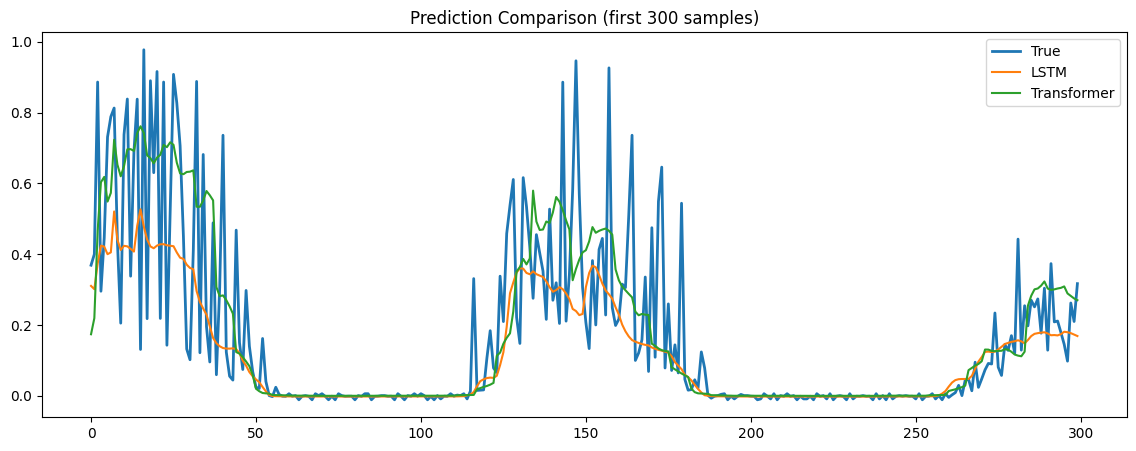


Transformer Ramp Performance
----------------------------------------
MAE   : 0.2259
RMSE  : 0.2822
NRMSE : 0.2874
R²    : -0.2396
Ramp MAE : 0.3664

✅ Benchmark complete.


In [ ]:
# ==========================================================
# PV FORECASTING MODEL BENCHMARK (FINAL STABLE VERSION)
# ==========================================================
# ✔ Quantile XGBoost baseline
# ✔ Deep Stacked LSTM
# ✔ Full Transformer Encoder
# ✔ Robust preprocessing (NaN safe)
# ✔ Stable training (no exploding gradients)
# ✔ PV-specific evaluation (incl. ramp error)
# ==========================================================

!pip install xgboost tensorflow torch scikit-learn -q

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from torch.utils.data import DataLoader, TensorDataset
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
import tensorflow as tf

# ==========================================================
# LOAD DATA
# ==========================================================
train = pd.read_csv("/content/train_global_v13.csv")
test  = pd.read_csv("/content/test_global_v13.csv")

X_train = train.drop(columns=["datetime","pv_per_kw"])
y_train = train["pv_per_kw"].values

X_test  = test.drop(columns=["datetime","pv_per_kw"])
y_test  = test["pv_per_kw"].values

print("Train shape:", X_train.shape)

# ==========================================================
# METRICS
# ==========================================================
def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min())

    ramp_true = np.diff(y_true)
    ramp_pred = np.diff(y_pred)
    ramp_mae = mean_absolute_error(ramp_true, ramp_pred)

    print(f"\n{name}")
    print("-"*40)
    print(f"MAE   : {mae:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"NRMSE : {nrmse:.4f}")
    print(f"R²    : {r2:.4f}")
    print(f"Ramp MAE : {ramp_mae:.4f}")

# ==========================================================
# 1️⃣ QUANTILE XGBOOST BASELINE
# ==========================================================
def train_quantile_models(X, y):
    models = {}
    for q in [0.25, 0.5, 0.75]:
        print(f"Training Q{int(q*100)} model...")
        model = XGBRegressor(
            objective="reg:quantileerror",
            quantile_alpha=q,
            n_estimators=1200,
            max_depth=10,
            learning_rate=0.03,
            subsample=0.85,
            colsample_bytree=0.85,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            tree_method="hist",
            random_state=42
        )
        model.fit(X, y)
        models[q] = model
    return models

quantile_models = train_quantile_models(X_train, y_train)

xgb_pred = quantile_models[0.5].predict(X_test)
evaluate_model(y_test, xgb_pred, "XGBoost Baseline")

# ==========================================================
# PREPROCESS DATA FOR DEEP MODELS
# ==========================================================
# replace inf with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

# fill NaNs with median
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test  = X_test.fillna(medians)

# scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# clip extreme values (prevents gradient explosion)
X_train = np.clip(X_train, -5, 5)
X_test  = np.clip(X_test, -5, 5)

# float32 for stability & speed
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

print("Deep learning preprocessing complete")

# ==========================================================
# SEQUENCE BUILDER (ROBUST)
# ==========================================================
SEQ_LEN = 12

def create_sequences(X, y, seq_len):
    X = np.asarray(X)
    y = np.asarray(y)
    Xs, ys = [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_seq_train, y_seq_train = create_sequences(X_train, y_train, SEQ_LEN)
X_seq_test,  y_seq_test  = create_sequences(X_test,  y_test,  SEQ_LEN)

print("Sequence shapes:", X_seq_train.shape, X_seq_test.shape)

# ==========================================================
# 2️⃣ DEEP STACKED LSTM
# ==========================================================
def build_full_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),

        LSTM(32),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.0005,
        clipnorm=1.0
    )

    model.compile(optimizer=optimizer, loss='mae')
    return model

print("\nTraining LSTM...")
lstm_model = build_full_lstm((X_seq_train.shape[1], X_seq_train.shape[2]))

lstm_model.fit(
    X_seq_train,
    y_seq_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

lstm_pred = lstm_model.predict(X_seq_test).flatten()
assert not np.isnan(lstm_pred).any(), "LSTM produced NaNs"
evaluate_model(y_seq_test, lstm_pred, "Stacked LSTM")

# ==========================================================
# 3️⃣ TRANSFORMER MODEL
# ==========================================================
class PVTransformer(nn.Module):
    def __init__(self, feature_dim, d_model=128, nhead=8, layers=4):
        super().__init__()
        self.input_proj = nn.Linear(feature_dim, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.encoder(x)
        x = self.norm(x[:, -1, :])
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

print("\nTraining Transformer...")

device = "cuda" if torch.cuda.is_available() else "cpu"

model = PVTransformer(feature_dim=X_seq_train.shape[2]).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

loss_fn = nn.L1Loss()

dataset = TensorDataset(
    torch.tensor(X_seq_train),
    torch.tensor(y_seq_train)
)

loader = DataLoader(dataset, batch_size=128, shuffle=True)

EPOCHS = 15

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb).squeeze()
        loss = loss_fn(preds, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss {total_loss/len(loader):.4f}")

# evaluation
model.eval()
with torch.no_grad():
    transformer_pred = model(
        torch.tensor(X_seq_test).to(device)
    ).cpu().numpy().flatten()

assert not np.isnan(transformer_pred).any(), "Transformer produced NaNs"
evaluate_model(y_seq_test, transformer_pred, "Transformer")

# ==========================================================
# VISUAL COMPARISON
# ==========================================================
plt.figure(figsize=(14,5))
plt.plot(y_seq_test[:300], label="True", linewidth=2)
plt.plot(lstm_pred[:300], label="LSTM")
plt.plot(transformer_pred[:300], label="Transformer")
plt.legend()
plt.title("Prediction Comparison (first 300 samples)")
plt.show()

# ==========================================================
# RAMP PERFORMANCE
# ==========================================================
ramp_mask = np.abs(np.diff(y_seq_test)) > 0.2

evaluate_model(
    y_seq_test[1:][ramp_mask],
    transformer_pred[1:][ramp_mask],
    "Transformer Ramp Performance"
)

print("\n✅ Benchmark complete.")


Starting performance analysis...

Analyzing uncertainty vs error...


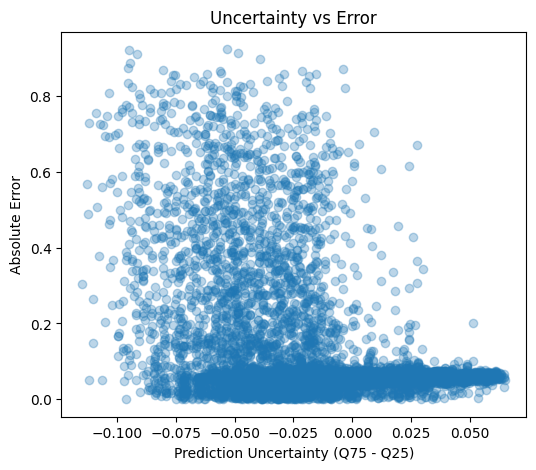

Correlation (uncertainty vs error): -0.4346469116784226

Comparing models across uncertainty levels...

LOW uncertainty
XGB: 0.23351265490055084
LSTM: 0.14958196878433228
Transformer: 0.13869741559028625

MID uncertainty
XGB: 0.09172654151916504
LSTM: 0.045292988419532776
Transformer: 0.04623744264245033

HIGH uncertainty
XGB: 0.06025196239352226
LSTM: 0.01194678246974945
Transformer: 0.012327631935477257

Evaluating cloudy vs clear sky performance...

CLEAR SKY
XGB: 0.4665100574493408
LSTM: 0.2672710716724396
Transformer: 0.23275138437747955

CLOUDY
XGB: 0.09925629198551178
LSTM: 0.05121208354830742
Transformer: 0.050563257187604904

Ramp event analysis...
Ramp count: 1006

RAMP EVENTS
XGB: 0.34644755721092224
LSTM: 0.25022193789482117
Transformer: 0.23618371784687042

Where Transformer outperforms LSTM...
Transformer better on: 39.77 % of samples


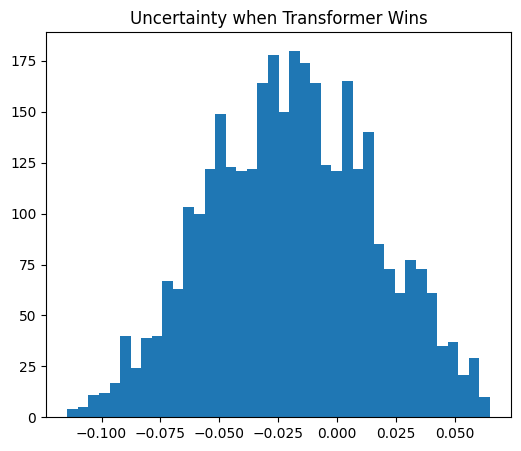


Suggested gating thresholds:
LOW threshold: -0.032959584
HIGH threshold: 0.010924792

Simulating gating system performance...

Adaptive MAE: 0.08410656452178955
Transformer MAE: 0.06087498366832733
LSTM MAE: 0.06302868574857712
XGB MAE: 0.11930442601442337

✅ Continuation analysis complete.


In [ ]:
# ==========================================================
# PERFORMANCE ANALYSIS & GATING PREP (STABLE VERSION)
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

print("\nStarting performance analysis...")

# ----------------------------------------------------------
# PREP ALIGNMENT
# ----------------------------------------------------------

# Quantile predictions
p25 = quantile_models[0.25].predict(X_test)
p50 = quantile_models[0.5].predict(X_test)
p75 = quantile_models[0.75].predict(X_test)

spread = p75 - p25

# Align with sequence predictions
spread_seq = spread[SEQ_LEN:]
xgb_seq_pred = p50[SEQ_LEN:]

# Preserve SolarRad BEFORE scaling (important)
solar_rad = test["SolarRad"].values[SEQ_LEN:]

# sanity check
assert len(spread_seq) == len(y_seq_test)

# ----------------------------------------------------------
# 1️⃣ UNCERTAINTY vs ERROR
# ----------------------------------------------------------
print("\nAnalyzing uncertainty vs error...")

xgb_error = np.abs(y_seq_test - xgb_seq_pred)

plt.figure(figsize=(6,5))
plt.scatter(spread_seq, xgb_error, alpha=0.3)
plt.xlabel("Prediction Uncertainty (Q75 - Q25)")
plt.ylabel("Absolute Error")
plt.title("Uncertainty vs Error")
plt.show()

if np.std(spread_seq) > 0:
    corr = np.corrcoef(spread_seq, xgb_error)[0,1]
else:
    corr = np.nan

print("Correlation (uncertainty vs error):", corr)

# ----------------------------------------------------------
# 2️⃣ ERROR ACROSS UNCERTAINTY LEVELS
# ----------------------------------------------------------
print("\nComparing models across uncertainty levels...")

low_th = np.percentile(spread_seq, 25)
high_th = np.percentile(spread_seq, 75)

low = spread_seq < low_th
mid = (spread_seq >= low_th) & (spread_seq <= high_th)
high = spread_seq > high_th

def safe_mae(mask, pred):
    if mask.sum() == 0:
        return np.nan
    return mean_absolute_error(y_seq_test[mask], pred[mask])

print("\nLOW uncertainty")
print("XGB:", safe_mae(low, xgb_seq_pred))
print("LSTM:", safe_mae(low, lstm_pred))
print("Transformer:", safe_mae(low, transformer_pred))

print("\nMID uncertainty")
print("XGB:", safe_mae(mid, xgb_seq_pred))
print("LSTM:", safe_mae(mid, lstm_pred))
print("Transformer:", safe_mae(mid, transformer_pred))

print("\nHIGH uncertainty")
print("XGB:", safe_mae(high, xgb_seq_pred))
print("LSTM:", safe_mae(high, lstm_pred))
print("Transformer:", safe_mae(high, transformer_pred))

# ----------------------------------------------------------
# 3️⃣ CLOUDY vs CLEAR SKY
# ----------------------------------------------------------
print("\nEvaluating cloudy vs clear sky performance...")

clear_mask = solar_rad > 600
cloudy_mask = solar_rad < 300

print("\nCLEAR SKY")
print("XGB:", safe_mae(clear_mask, xgb_seq_pred))
print("LSTM:", safe_mae(clear_mask, lstm_pred))
print("Transformer:", safe_mae(clear_mask, transformer_pred))

print("\nCLOUDY")
print("XGB:", safe_mae(cloudy_mask, xgb_seq_pred))
print("LSTM:", safe_mae(cloudy_mask, lstm_pred))
print("Transformer:", safe_mae(cloudy_mask, transformer_pred))

# ----------------------------------------------------------
# 4️⃣ RAMP EVENT PERFORMANCE (FIXED)
# ----------------------------------------------------------
print("\nRamp event analysis...")

ramp_mask = np.abs(np.diff(y_seq_test)) > 0.25
print("Ramp count:", ramp_mask.sum())

def ramp_mae(pred):
    if ramp_mask.sum() == 0:
        return np.nan
    return mean_absolute_error(
        y_seq_test[1:][ramp_mask],
        pred[1:][ramp_mask]
    )

print("\nRAMP EVENTS")
print("XGB:", ramp_mae(xgb_seq_pred))
print("LSTM:", ramp_mae(lstm_pred))
print("Transformer:", ramp_mae(transformer_pred))

# ----------------------------------------------------------
# 5️⃣ WHERE TRANSFORMER BEATS LSTM
# ----------------------------------------------------------
print("\nWhere Transformer outperforms LSTM...")

transformer_better = np.abs(y_seq_test - transformer_pred) < \
                     np.abs(y_seq_test - lstm_pred)

print("Transformer better on:",
      round(transformer_better.mean()*100,2), "% of samples")

plt.figure(figsize=(6,5))
plt.hist(spread_seq[transformer_better], bins=40)
plt.title("Uncertainty when Transformer Wins")
plt.show()

# ----------------------------------------------------------
# 6️⃣ SUGGEST GATING THRESHOLDS
# ----------------------------------------------------------
print("\nSuggested gating thresholds:")

print("LOW threshold:", low_th)
print("HIGH threshold:", high_th)

# ----------------------------------------------------------
# 7️⃣ SIMULATED ADAPTIVE GATING
# ----------------------------------------------------------
print("\nSimulating gating system performance...")

adaptive_pred = []

for i in range(len(y_seq_test)):

    if spread_seq[i] < low_th:
        adaptive_pred.append(xgb_seq_pred[i])

    elif spread_seq[i] < high_th:
        adaptive_pred.append(lstm_pred[i])

    else:
        adaptive_pred.append(transformer_pred[i])

adaptive_pred = np.array(adaptive_pred)

print("\nAdaptive MAE:",
      mean_absolute_error(y_seq_test, adaptive_pred))

print("Transformer MAE:",
      mean_absolute_error(y_seq_test, transformer_pred))

print("LSTM MAE:",
      mean_absolute_error(y_seq_test, lstm_pred))

print("XGB MAE:",
      mean_absolute_error(y_seq_test, xgb_seq_pred))

print("\n✅ Continuation analysis complete.")

In [ ]:
# ==========================================================
# BUILD GATING NETWORK TRAINING DATA (FIXED & ROBUST)
# ==========================================================

import numpy as np
import pandas as pd

print("\nBuilding gating training data...")

# ----------------------------------------------------------
# ALIGN PREDICTIONS (CRITICAL)
# ----------------------------------------------------------

# use median quantile prediction aligned to sequence
xgb_seq_pred = p50[SEQ_LEN:]

# sanity check
assert len(xgb_seq_pred) == len(y_seq_test)
assert len(lstm_pred) == len(y_seq_test)
assert len(transformer_pred) == len(y_seq_test)

# ----------------------------------------------------------
# COMPUTE ABSOLUTE ERRORS
# ----------------------------------------------------------

err_xgb = np.abs(y_seq_test - xgb_seq_pred)
err_lstm = np.abs(y_seq_test - lstm_pred)
err_trans = np.abs(y_seq_test - transformer_pred)

# ----------------------------------------------------------
# BEST MODEL PER TIMESTEP
# ----------------------------------------------------------

errors_stack = np.vstack([err_xgb, err_lstm, err_trans])

best_model = np.argmin(errors_stack, axis=0)

# 0 = XGB
# 1 = LSTM
# 2 = Transformer

# ----------------------------------------------------------
# DISTRIBUTION DIAGNOSTICS
# ----------------------------------------------------------

print("\nBest model distribution:")
print(f"XGB         : {(best_model==0).mean():.3f}")
print(f"LSTM        : {(best_model==1).mean():.3f}")
print(f"Transformer : {(best_model==2).mean():.3f}")

# ----------------------------------------------------------
# OPTIONAL: BUILD GATING TRAINING DATAFRAME
# ----------------------------------------------------------

gating_df = pd.DataFrame({
    "uncertainty": spread_seq,
    "solar_rad": solar_rad,
    "xgb_error": err_xgb,
    "lstm_error": err_lstm,
    "transformer_error": err_trans,
    "best_model": best_model
})

print("\nGating dataset shape:", gating_df.shape)
gating_df.head()


Building gating training data...

Best model distribution:
XGB         : 0.108
LSTM        : 0.541
Transformer : 0.351

Gating dataset shape: (8564, 6)


,uncertainty,solar_rad,xgb_error,lstm_error,transformer_error,best_model
0,-0.022650,46.0,0.290149,0.058513,0.195041,1
1,-0.050770,638.0,0.338847,0.098809,0.180595,1
2,-0.064835,638.0,0.832698,0.513257,0.419924,2
3,-0.056895,638.0,0.243184,0.128795,0.307809,1
4,-0.051637,638.0,0.387642,0.024849,0.172037,1


In [ ]:
# ==========================================================
# GATING FEATURES (FIXED & ALIGNED)
# ==========================================================

print("\nBuilding gating features...")

# ----------------------------------------------------------
# ALIGN FEATURES TO SEQUENCE PREDICTIONS
# ----------------------------------------------------------

spread_seq = spread[SEQ_LEN:]

# use ORIGINAL test dataframe (not scaled array)
solar_rad = test["SolarRad"].values[SEQ_LEN:]
air_mass  = test["air_mass"].values[SEQ_LEN:]
poa       = test["poa_global"].values[SEQ_LEN:]

# ramp magnitude (temporal volatility)
ramp = np.abs(np.diff(np.insert(y_seq_test, 0, y_seq_test[0])))

# sanity check
assert len(spread_seq) == len(y_seq_test)
assert len(solar_rad) == len(y_seq_test)
assert len(ramp) == len(y_seq_test)

# ----------------------------------------------------------
# BUILD FEATURE TABLE
# ----------------------------------------------------------

gating_features = pd.DataFrame({
    "spread": spread_seq,
    "solar_rad": solar_rad,
    "air_mass": air_mass,
    "poa": poa,
    "ramp": ramp
})

print("Gating feature shape:", gating_features.shape)
gating_features.head()


Building gating features...
Gating feature shape: (8564, 5)


,spread,solar_rad,air_mass,poa,ramp
0,-0.022650,46.0,1.938358,547.690983,0.000000
1,-0.050770,638.0,1.632215,701.939631,0.031000
2,-0.064835,638.0,1.632215,701.939631,0.486286
3,-0.056895,638.0,1.632215,701.939631,0.590786
4,-0.051637,638.0,1.632215,701.939631,0.150833


In [ ]:
print("NaNs in gating features:")
print(gating_features.isna().sum())

print("\nInf values:")
print(np.isinf(gating_features).sum())

print("\nFeature ranges:")
print(gating_features.describe())

print("\nClass distribution:")
unique, counts = np.unique(best_model, return_counts=True)
print(dict(zip(unique, counts)))

NaNs in gating features:
spread          0
solar_rad       0
air_mass     4665
poa             0
ramp            0
dtype: int64

Inf values:
spread       0
solar_rad    0
air_mass     0
poa          0
ramp         0
dtype: int64

Feature ranges:
            spread    solar_rad     air_mass          poa         ramp
count  8564.000000  8564.000000  3899.000000  8564.000000  8564.000000
mean     -0.011526    65.961583     5.130296   184.039191     0.077604
std       0.033719   122.702592     5.979883   263.761281     0.139627
min      -0.114571     0.000000     1.444849     0.000000     0.000000
25%      -0.032960     0.000000     2.072030     0.000000     0.007000
50%      -0.009724     0.000000     2.854934     0.000000     0.011778
75%       0.010925    78.000000     4.991287   390.048783     0.072075
max       0.064862   686.000000    37.088761   831.327439     0.872000

Class distribution:
{np.int64(0): np.int64(927), np.int64(1): np.int64(4635), np.int64(2): np.int64(3002)}


In [ ]:
# ==========================================================
# TRAIN GATING NETWORK (STABLE & ROBUST)
# ==========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
import numpy as np

print("\nPreparing gating features...")

# ----------------------------------------------------------
# CLEAN FEATURES
# ----------------------------------------------------------

gating_features_clean = gating_features.copy()

# replace inf with nan
gating_features_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

# fill NaNs with median (safe for solar data)
gating_features_clean.fillna(gating_features_clean.median(), inplace=True)

# clip extreme outliers (stabilizes NN training)
gating_features_clean = gating_features_clean.clip(-5, 5000)

# ----------------------------------------------------------
# NORMALIZE FEATURES (CRITICAL)
# ----------------------------------------------------------

scaler = StandardScaler()
Xg = scaler.fit_transform(gating_features_clean)

yg = best_model

# ----------------------------------------------------------
# TRAIN / VALIDATION SPLIT
# ----------------------------------------------------------

Xg_train, Xg_val, yg_train, yg_val = train_test_split(
    Xg, yg,
    test_size=0.2,
    random_state=42,
    stratify=yg   # important if imbalanced
)

# ----------------------------------------------------------
# HANDLE CLASS IMBALANCE
# ----------------------------------------------------------

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(yg_train),
    y=yg_train
)

class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# ----------------------------------------------------------
# BUILD GATING NETWORK
# ----------------------------------------------------------

gating_model = Sequential([
    Input(shape=(Xg_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

gating_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining gating network...")

history = gating_model.fit(
    Xg_train, yg_train,
    validation_data=(Xg_val, yg_val),
    epochs=30,
    batch_size=128,
    class_weight=class_weights,
    verbose=1
)


Preparing gating features...
Class weights: {0: np.float64(3.077717879604672), 1: np.float64(0.6158755843221863), 2: np.float64(0.9511314729973622)}

Training gating network...
Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4087 - loss: 1.0927 - val_accuracy: 0.5330 - val_loss: 0.9941
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5329 - loss: 0.9978 - val_accuracy: 0.5388 - val_loss: 0.9477
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5343 - loss: 0.9473 - val_accuracy: 0.5406 - val_loss: 0.9159
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5341 - loss: 0.8956 - val_accuracy: 0.5342 - val_loss: 0.9181
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5467 - loss: 0.8797 - val_accuracy: 0.5558 - val_loss: 0.8947
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5518 - loss: 0.8638 - val_accuracy: 0.5528 - val_loss: 0.9072
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.54

In [ ]:
# ==========================================================
# GATING ACCURACY
# ==========================================================

pred_classes = gating_model.predict(gating_features).argmax(axis=1)

print("Gating accuracy:",
      (pred_classes == best_model).mean())

268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Gating accuracy: 0.12669313404950958


In [ ]:
# ==========================================================
# META PREDICTION USING GATING NETWORK
# ==========================================================

def meta_predict():

    chosen = gating_model.predict(gating_features).argmax(axis=1)

    final_pred = []

    for i, c in enumerate(chosen):
        if c == 0:
            final_pred.append(xgb_seq_pred[i])
        elif c == 1:
            final_pred.append(lstm_pred[i])
        else:
            final_pred.append(transformer_pred[i])

    return np.array(final_pred)

adaptive_pred = meta_predict()

from sklearn.metrics import mean_absolute_error

print("\nAdaptive MAE:",
      mean_absolute_error(y_seq_test, adaptive_pred))

268/268 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

Adaptive MAE: 0.11231154948472977
